In [131]:
import pandas as pd

In [132]:
df=pd.read_csv("spam.csv",encoding='latin-1')

In [133]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


# Data Cleaning

In [134]:
df.shape

(5572, 5)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [136]:
#drop unwanted columns
df=df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"])

In [137]:
df.rename(columns={"v1":"target","v2":"text"},inplace=True)

In [138]:
df

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [139]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [140]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [141]:
df["target"]=encoder.fit_transform(df["target"])

In [142]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [143]:
df.duplicated().sum()

403

In [144]:
df=df.drop_duplicates(keep="first")

In [145]:
df.duplicated().sum()

0

In [146]:
df.shape

(5169, 2)

# EDA

In [147]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

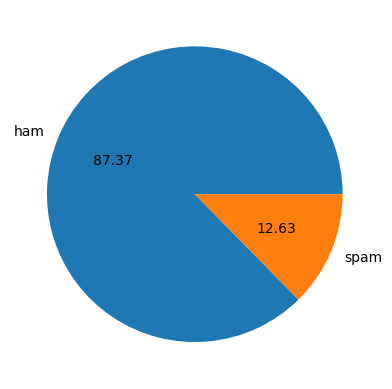

In [148]:
import matplotlib.pyplot as plt
plt.pie(df["target"].value_counts(),labels=["ham","spam"],autopct="%0.2f")
plt.show()

In [149]:
#imbalance data

In [150]:
import nltk

In [151]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hello\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [152]:
df["char_count"]=df["text"].apply(len)

C:\Users\Hello\AppData\Local\Temp\ipykernel_22392\1152397323.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["char_count"]=df["text"].apply(len)


In [153]:
df.head()

,target,text,char_count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [154]:
df["word_count"]=df["text"].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\Hello\AppData\Local\Temp\ipykernel_22392\2294843812.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["word_count"]=df["text"].apply(lambda x:len(nltk.word_tokenize(x)))


In [155]:
df.head()

,target,text,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [156]:
df["sentence_count"]=df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\Hello\AppData\Local\Temp\ipykernel_22392\3680672249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentence_count"]=df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))


In [157]:
df

,target,text,char_count,word_count,sentence_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [158]:
df[["char_count","word_count","sentence_count"]].describe()

,char_count,word_count,sentence_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [159]:
df[df["target"]==0][["char_count","word_count","sentence_count"]].describe()

,char_count,word_count,sentence_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [160]:
df[df["target"]==1][["char_count","word_count","sentence_count"]].describe()

,char_count,word_count,sentence_count
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [161]:
import seaborn as sns

<Axes: xlabel='char_count', ylabel='Count'>

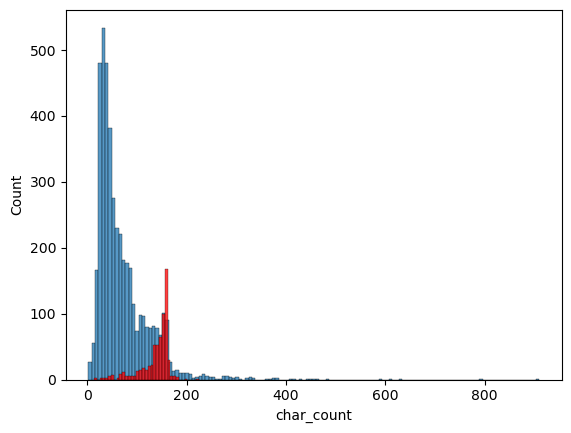

In [162]:
sns.histplot(df[df["target"]==0]["char_count"])
sns.histplot(df[df["target"]==1]["char_count"],color="red")

<Axes: xlabel='word_count', ylabel='Count'>

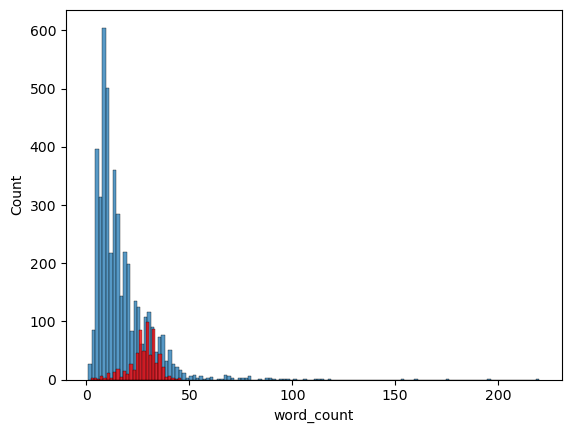

In [163]:
sns.histplot(df[df["target"]==0]["word_count"])
sns.histplot(df[df["target"]==1]["word_count"],color="red")

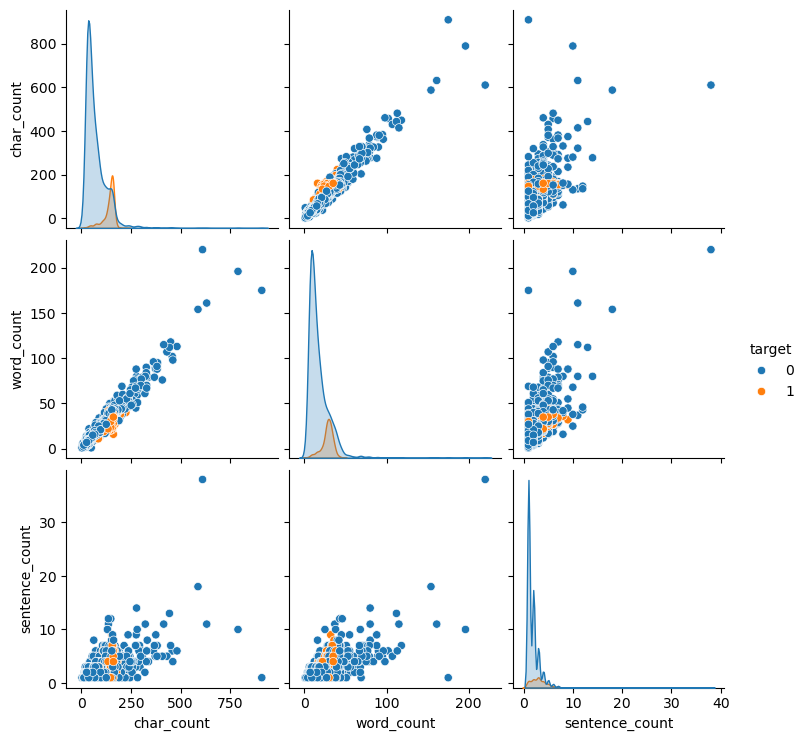

In [164]:
sns.pairplot(df,hue="target")

In [165]:
ddf=df.drop(columns="text")

<Axes: >

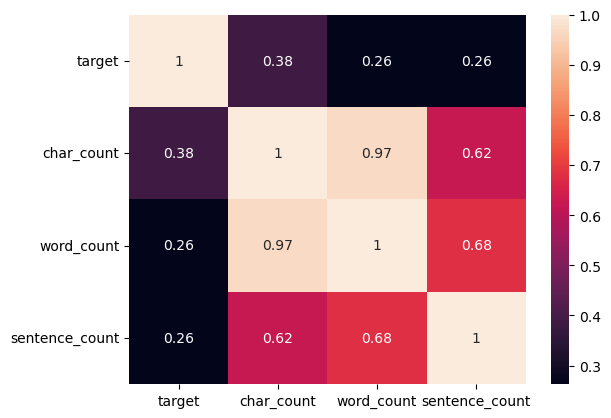

In [166]:
sns.heatmap(ddf.corr(),annot=True)

# Data Preprocessing

In [167]:
import string
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    lst=[]
    for i in text:
        if i.isalnum():
            lst.append(i)
    text=list(lst)
    lst.clear()
    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            lst.append(i)
    text=lst[:]
    lst.clear()
    for i in text:
        lst.append(ps.stem(i))
        
    return " ".join(lst)

In [168]:
from nltk.corpus import stopwords

In [169]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [170]:
df["transform_text"]=df["text"].apply(transform_text)

C:\Users\Hello\AppData\Local\Temp\ipykernel_22392\733104182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transform_text"]=df["text"].apply(transform_text)


In [171]:
df

,target,text,char_count,word_count,sentence_count,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [172]:
pip install wordcloud

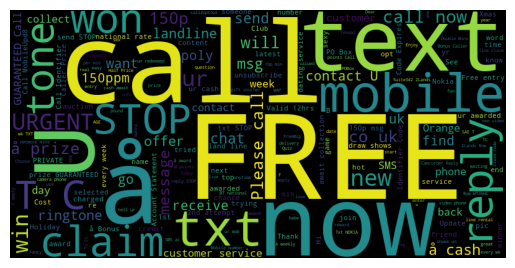

In [173]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
spam_words=" ".join(df[df["target"]==1]["text"])
wordcloud=WordCloud(width=800,height=400).generate(spam_words)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

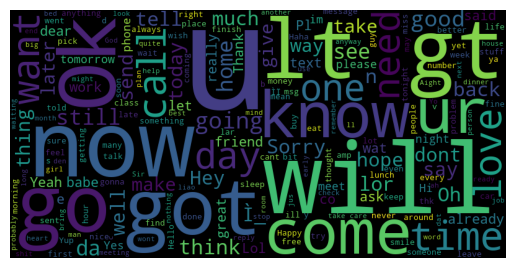

In [174]:
spam_words=" ".join(df[df["target"]==0]["text"])
wordcloud=WordCloud(width=800,height=400).generate(spam_words)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [175]:
spam_corpus=[]
for msg in df[df["target"]==1]["transform_text"].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [176]:
len(spam_corpus)

9939

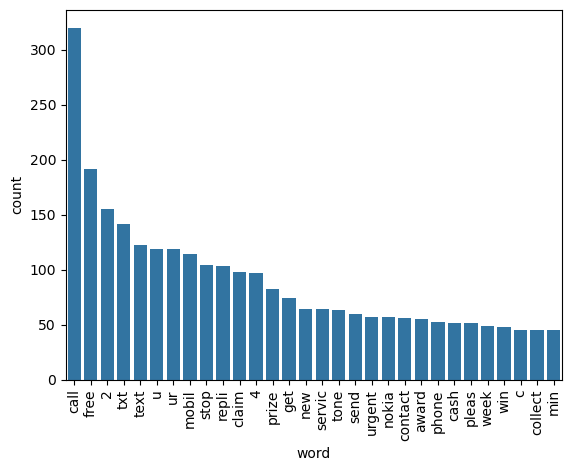

In [177]:
from collections import Counter
common_words=pd.DataFrame(Counter(spam_corpus).most_common(30),columns=["word","count"])
sns.barplot(data=common_words,x="word",y="count")
plt.xticks(rotation=90)
plt.show()

In [178]:
ham_corpus=[]
for msg in df[df["target"]==0]["transform_text"].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [179]:
len(ham_corpus)

35404

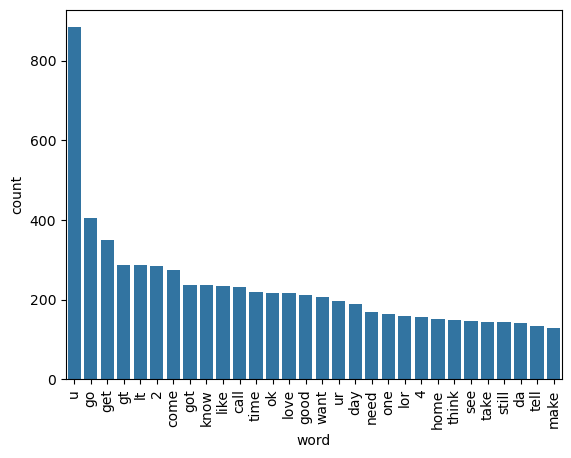

In [180]:
common_words=pd.DataFrame(Counter(ham_corpus).most_common(30),columns=["word","count"])
sns.barplot(data=common_words,x="word",y="count")
plt.xticks(rotation=90)
plt.show()

# model building

In [181]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=3000)
X=tfidf.fit_transform(df["text"]).toarray()
y=df["target"]

In [182]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [183]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
mnb=MultinomialNB()
gnb=GaussianNB()
bnb=BernoulliNB()

In [184]:
mnb.fit(X_train,y_train)

MultinomialNB()

In [185]:
y_pred1=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.97678916827853
[[889   0]
 [ 24 121]]
1.0


In [186]:
gnb.fit(X_train,y_train)

GaussianNB()

In [187]:
y_pred2=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.8907156673114119
[[797  92]
 [ 21 124]]
0.5740740740740741


In [188]:
bnb.fit(X_train,y_train)

BernoulliNB()

In [189]:
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9825918762088974
[[887   2]
 [ 16 129]]
0.9847328244274809


In [190]:
from sklearn.linear_model import LogisticRegression

In [191]:
lg=LogisticRegression(max_iter=1000)

In [192]:
lg.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [193]:
y_pred4=lg.predict(X_test)
print(accuracy_score(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))
print(precision_score(y_test,y_pred4))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


In [194]:
from sklearn.ensemble import RandomForestClassifier

In [195]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [196]:
y_pred4=rf.predict(X_test)
print(accuracy_score(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))
print(precision_score(y_test,y_pred4))

0.9796905222437138
[[888   1]
 [ 20 125]]
0.9920634920634921


In [197]:
from sklearn.neighbors import KNeighborsClassifier

In [198]:
knc=KNeighborsClassifier()

In [199]:
knc.fit(X_train,y_train)

KNeighborsClassifier()

In [200]:
y_pred4=knc.predict(X_test)
print(accuracy_score(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))
print(precision_score(y_test,y_pred4))

0.9110251450676983
[[889   0]
 [ 92  53]]
1.0


In [201]:
from sklearn.svm import SVC

In [202]:
svc=SVC(kernel="sigmoid",gamma=1.0)

In [203]:
svc.fit(X_train,y_train)

SVC(gamma=1.0, kernel='sigmoid')

In [204]:
y_pred4=svc.predict(X_test)
print(accuracy_score(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred4))
print(precision_score(y_test,y_pred4))

0.9874274661508704
[[886   3]
 [ 10 135]]
0.9782608695652174


In [205]:
clfs={
    "MNB":mnb,
    "LG":lg,
    "SVC":svc,
    "KNC":knc,
    "GNB":gnb,
    "BNB":bnb
}

In [206]:
def train_models(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    return accuracy,precision

In [207]:
accuracy_scores=[]
precision_scores=[]
for i,j in clfs.items():
    current_accuracy,current_precision=train_models(j,X_train,y_train,X_test,y_test)
    print("for",i)
    print("accuracy :",current_accuracy)
    print("precision",current_precision)
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    

for MNB
accuracy : 0.97678916827853
precision 1.0
for LG
accuracy : 0.9661508704061895
precision 0.9661016949152542
for SVC
accuracy : 0.9874274661508704
precision 0.9782608695652174
for KNC
accuracy : 0.9110251450676983
precision 1.0
for GNB
accuracy : 0.8907156673114119
precision 0.5740740740740741
for BNB
accuracy : 0.9825918762088974
precision 0.9847328244274809


In [208]:
performance_df=pd.DataFrame({"Algorithm":clfs.keys(),"Accuracy":accuracy_scores,"Precision":precision_scores}).sort_values("Precision",ascending=False)

In [209]:
performance_df

,Algorithm,Accuracy,Precision
0,MNB,0.976789,1.000000
3,KNC,0.911025,1.000000
5,BNB,0.982592,0.984733
2,SVC,0.987427,0.978261
1,LG,0.966151,0.966102
4,GNB,0.890716,0.574074


In [211]:
import pickle
pickle.dump(tfidf,open("vectorizer.pkl","wb"))
pickle.dump(mnb,open("model.pkl","wb"))